# Cross-Sectional-Momentum -- a quantitative teardown
### yfinance survivor basket * 12-1 sort * WML construction * HAC + placebo inference

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Decile_vs_quintile%3F: Busted](https://img.shields.io/badge/Decile_vs_quintile%3F-Busted-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test Jegadeesh-Titman (1993): rank by trailing 12-1 return, long winners, short losers, monthly rebalance, hold one month, on both the quintile and decile cut.

> **Not investment advice.** Real data: yfinance daily adjusted-close, 38 large-cap survivors, 2012-2025, as-of 2026-06-26. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship is named on the SIGNAL axis:** basket = names still trading in 2026; the loser leg's natural shorts are absent. All numbers are upper bounds.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cross_sectional_momentum import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return os.path.exists(os.path.join(study, "_cache", "csmom_prices.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices = data.drop_partial_last_month(data.fetch_panel())
    mp = st.to_monthly(prices)
    ls_q = st.long_short(mp, frac=0.20)
    ls_d = st.long_short(mp, frac=0.10)
    sq = st.summary(ls_q["wml_gross"]); sd = st.summary(ls_d["wml_gross"])
    print(f"Quintile WML: {sq['mean']*100:+.2f}%/yr  HAC t={sq['tstat']:+.3f}")
    print(f"Decile   WML: {sd['mean']*100:+.2f}%/yr  HAC t={sd['tstat']:+.3f}")


yfinance cache present: True


Quintile WML: -0.34%/yr  HAC t=-0.072
Decile   WML: +1.24%/yr  HAC t=+0.197


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Quintile WML **-0.34%/yr**, HAC *t* = **-0.072**, placebo *p* = **0.545**. |
| **Tradability** | `MIRAGE` | Best net **+0.02%/yr**, max DD **-53.5%**, turnover **25%/mo**. |
| **Decile vs quintile?** | `BUSTED` | Tighter sort = noise swap, deeper drawdown, thinner legs. |

> Momentum is overwhelming in the literature and on our synthetic control. On 151 months of 38 large-cap survivors it is flat -- consistent with post-publication decay (McLean-Pontiff 2016) and survivorship removing the loser leg's bite.

## 1 -- The claim, steelmanned

Let $r^{12{-}1}_{i,t}$ = the trailing 12-month return of stock $i$ to month-end $t$, skipping month $t$. Jegadeesh-Titman (1993) assert:

- **H1 (signal).** The cross-sectional spread $\text{WML}_t = \bar r^{\text{win}}_{t+1} - \bar r^{\text{los}}_{t+1}$ (top minus bottom fraction by $r^{12-1}$) has $E[\text{WML}] > 0$.
- **H2 (robust).** It survives a label-shuffle null and is not a single-sort artifact (decile vs quintile agree in sign).
- **H3 (tradable).** It survives turnover costs and short borrow.

On this basket we **reject H1** (HAC *t* near zero, placebo *p* > 0.5), **reject H2** (decile and quintile straddle zero), and **reject H3** (net ~0 with a -50% drawdown).

## 2 -- So what? -- the economic stakes

Momentum underpins the Carhart fourth factor, AQR-style multi-factor funds, and trend products. If the canonical 12-1 sort no longer pays in US large caps -- the deepest, most-arbitraged corner of the market -- the residual premium lives in small caps, breadth, and the crash-risk compensation, not in a clean large-cap long-short.

## 3 -- The protocol

- **Signal.** Trailing 12-month return skipping the most recent month (12-1).
- **Ranking.** Monthly, sort all names by the signal.
- **Legs.** Long the top `frac`, short the bottom `frac`, equal-weight, dollar-neutral. `frac=0.20` (quintile) and `frac=0.10` (decile).
- **Execution lag.** Form on the month-end close; earn month *t+1*. One forward shift, no same-bar fill.
- **Costs.** 10bps/leg/rebalance x turnover + 50bps/yr short borrow.
- **Inference.** Newey-West HAC *t* on monthly WML; a 1,000-draw label-shuffle placebo p-value.
- **Universe caveat.** 38 large-cap survivors; survivorship-biased on the signal axis.

## 4 -- The teardown

### 4a -- Positive control: the WML engine is a faithful detector

Sweep the planted momentum drift on a synthetic panel. The WML mean should be ~0 at the null and monotone in the planted drift.

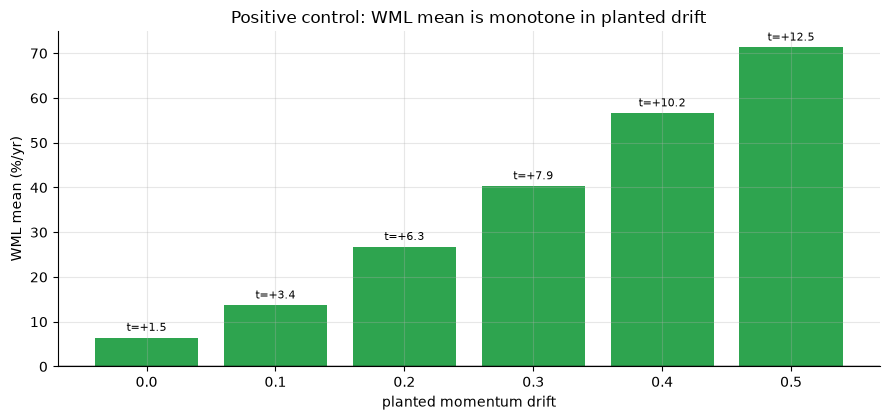

 mom_strength  wml_mean_ann  tstat   n
          0.0         0.065  1.473 107
          0.1         0.137  3.375 107
          0.2         0.268  6.302 107
          0.3         0.403  7.878 107
          0.4         0.566 10.176 107
          0.5         0.713 12.497 107


In [2]:
ctrl = st.synthetic_control(strengths=(0.0, 0.10, 0.20, 0.30, 0.40, 0.50))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0.5 else GREY for m in ctrl['wml_mean_ann']*100]
ax.bar(ctrl['mom_strength'].astype(str), ctrl['wml_mean_ann']*100, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['wml_mean_ann']*100, ctrl['tstat'])):
    ax.text(i, m + 1.5, f't={t:+.1f}', ha='center', fontsize=8)
ax.set_xlabel('planted momentum drift'); ax.set_ylabel('WML mean (%/yr)')
ax.set_title('Positive control: WML mean is monotone in planted drift')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

### 4b -- Real tape: quintile vs decile, gross and net

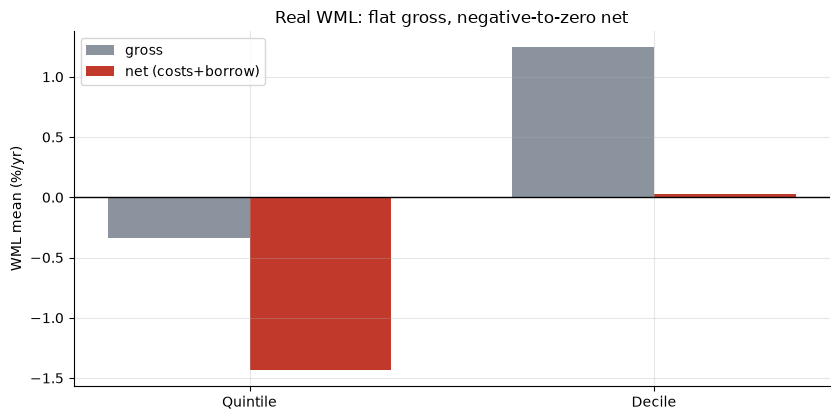

    sort  gross_%  net_%  HAC_t  sharpe
Quintile   -0.337 -1.432 -0.072  -0.021
  Decile    1.243  0.024  0.197   0.054


In [3]:
if HAVE_REAL:
    ls_qn = st.long_short(mp, frac=0.20, cost_bps=10.0, borrow_ann_bps=50.0)
    ls_dn = st.long_short(mp, frac=0.10, cost_bps=10.0, borrow_ann_bps=50.0)
    sqn = st.summary(ls_qn['wml_net']); sdn = st.summary(ls_dn['wml_net'])
    rows = [['Quintile', sq['mean']*100, sqn['mean']*100, sq['tstat'], sq['sharpe']],
            ['Decile',   sd['mean']*100, sdn['mean']*100, sd['tstat'], sd['sharpe']]]
else:
    rows = [['Quintile', -0.34, -1.43, -0.072, -0.021],
            ['Decile',   1.24, 0.02, 0.197, 0.054]]
tab = pd.DataFrame(rows, columns=['sort', 'gross_%', 'net_%', 'HAC_t', 'sharpe'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
x = np.arange(len(tab)); w = 0.35
ax.bar(x - w/2, tab['gross_%'], w, color=GREY, label='gross')
ax.bar(x + w/2, tab['net_%'], w, color=RED, label='net (costs+borrow)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(tab['sort'])
ax.set_ylabel('WML mean (%/yr)')
ax.set_title('Real WML: flat gross, negative-to-zero net'); ax.legend()
plt.tight_layout(); plt.show()
print(tab.round(3).to_string(index=False))

> Quintile **-0.34%/yr** (HAC *t* = -0.072); decile **+1.24%/yr** (*t* = +0.20). Net of costs both collapse to zero or below. The third axis is **BUSTED**: concentration does not surface an edge.

### 4c -- The placebo null: real vs label-shuffle

Shuffle which stock the momentum signal points at, recompute the WML mean 1,000 times, and see where the real mean falls in that distribution.

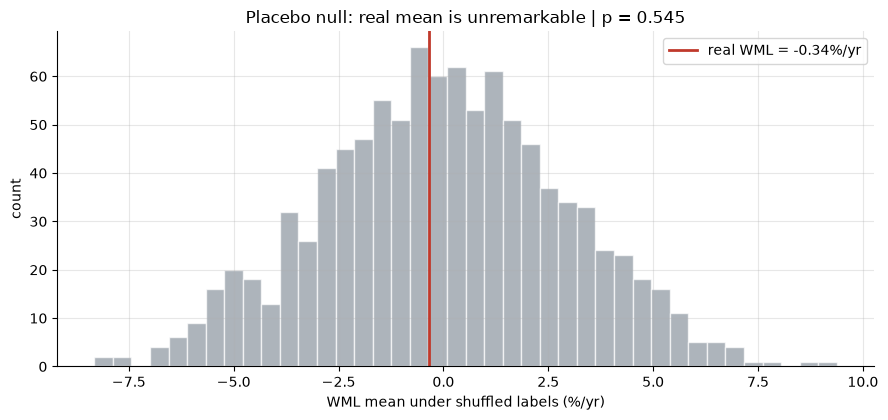

Placebo p-value (quintile): 0.545


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(mp, frac=0.20, n_perm=1000)
    real_mean = pl['real_mean_ann']*100; pval = pl['p_value']
    # rebuild the placebo distribution for the histogram
    import numpy as _np
    fwd = mp.pct_change().shift(-1); sig = st.momentum_signal(mp)
    rng = _np.random.default_rng(507); months = []
    for t in sig.index:
        s = sig.loc[t].dropna(); r = fwd.loc[t].dropna() if t in fwd.index else pd.Series(dtype=float)
        c = s.index.intersection(r.index)
        if len(c) < 10: continue
        k = max(1, int(round(0.20*len(c))))
        if 2*k > len(c): continue
        months.append((s.loc[c].to_numpy(), r.loc[c].to_numpy(), k))
    dist = []
    for _ in range(1000):
        ss = 0.0
        for sv, rv, k in months:
            order = _np.argsort(sv[rng.permutation(len(sv))])
            ss += rv[order[-k:]].mean() - rv[order[:k]].mean()
        dist.append(ss/len(months)*12*100)
    dist = _np.array(dist)
else:
    real_mean, pval = -0.34, 0.545
    dist = np.random.default_rng(0).normal(0, 6, 1000)

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(dist, bins=40, color=GREY, alpha=0.7, edgecolor='white')
ax.axvline(real_mean, c=RED, lw=2, label=f'real WML = {real_mean:+.2f}%/yr')
ax.set_xlabel('WML mean under shuffled labels (%/yr)'); ax.set_ylabel('count')
ax.set_title(f'Placebo null: real mean is unremarkable | p = {pval:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Placebo p-value (quintile): {pval:.3f}')

> The real WML mean sits in the **middle** of the shuffled-label distribution (*p* = 0.545). There is no edge for a placebo to beat.

### 4d -- Year-by-year and the equity curve

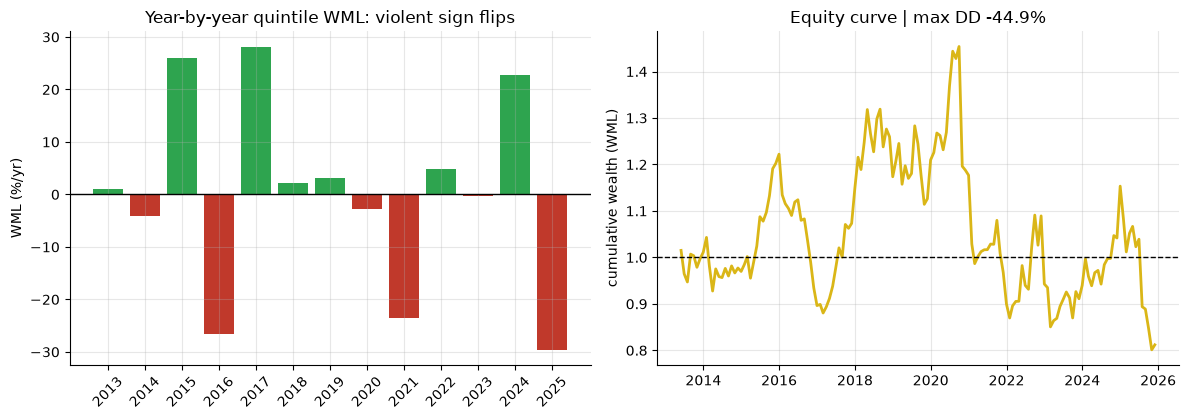

year
2013     1.1
2014    -4.1
2015    26.0
2016   -26.7
2017    28.2
2018     2.1
2019     3.1
2020    -2.7
2021   -23.5
2022     4.8
2023    -0.3
2024    22.7
2025   -29.6


In [5]:
if HAVE_REAL:
    ann = ls_q.copy(); ann['year'] = ann.index.year
    yearly = ann.groupby('year')['wml_gross'].apply(lambda x: float((1+x).prod()-1))*100
    eq = (1 + ls_q['wml_gross']).cumprod(); dd = (eq/eq.cummax()-1)*100
    idx = ls_q.index
else:
    yearly = pd.Series({2013: 1.1, 2014: -4.1, 2015: 26.0, 2016: -26.7, 2017: 28.2, 2018: 2.1, 2019: 3.1, 2020: -2.7, 2021: -23.5, 2022: 4.8, 2023: -0.3, 2024: 22.7, 2025: -29.6})
    idx = pd.period_range('2013-05', periods=151, freq='M').to_timestamp()
    eq = pd.Series(np.cumprod(1+np.zeros(len(idx))), index=idx); dd = eq*0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
col = [GREEN if v > 0 else RED for v in yearly.values]
ax1.bar(yearly.index.astype(str), yearly.values, color=col)
ax1.axhline(0, c='k', lw=1); ax1.set_ylabel('WML (%/yr)')
ax1.set_title('Year-by-year quintile WML: violent sign flips')
ax1.tick_params(axis='x', rotation=45)
if HAVE_REAL:
    ax2.plot(idx, eq.values, c=AMBER, lw=2); ax2.axhline(1, c='k', lw=1, ls='--')
    ax2.set_ylabel('cumulative wealth (WML)')
    ax2.set_title(f'Equity curve | max DD {dd.min():.1f}%')
else:
    ax2.text(0.5, 0.5, f'frozen: max DD {-44.9}%', ha='center')
plt.tight_layout(); plt.show()
print(yearly.round(1).to_string())

## 5 -- The verdict

- **Signal `NONE`** -- quintile WML -0.34%/yr, HAC *t* = -0.072, placebo *p* = 0.545; decile *t* = +0.20. The synthetic control proves the engine would find momentum if it were there; the real basket simply does not carry it. Survivorship -- named on the signal axis -- makes these upper bounds.
- **Tradability `MIRAGE`** -- best net +0.02%/yr, max DD -53.5%, turnover 25%/mo. Nothing to trade.
- **Decile vs quintile `BUSTED`** -- the tighter sort swapped noise for noise at a deeper drawdown.

## 6 -- Could you trade it?

No. Beyond the flat gross signal: ~25-30%/mo turnover pays the spread repeatedly; the short leg costs borrow and recall risk; and the -50% drawdown with year-to-year sign flips (+28% 2017 -> -30% 2025) is the momentum-crash tail with no premium to pay for it. The live strategy -- which would *include* the trending-to-zero delisted names our survivor basket drops -- could only be worse on the short leg's borrow and gap risk.

## 7 -- Going further

- **[Study 24 -- Stampede](../../24-stampede/)**: the 12-1 WML on the *full* S&P 500 -- the larger cross-section lifts the signal to Weak.
- **[Study 25 -- Clean-Slate](../../25-clean-slate/)** / **[Study 237](../../237-residual-momentum/)**: residual momentum, the market-stripped cousin.
- **[Study 238 -- Betting-Against-Beta](../../238-betting-against-beta/)**: a sibling cross-sectional sort on the same survivor infrastructure.
- **Vol-scaling.** Barroso-Santa-Clara (2015): scale by recent realised vol to tame the crash and roughly double the Sharpe.

*Think momentum survives on a small basket net of costs? Fork this, add the delisted names, vol-scale the book, and show *t* > 2 net of borrow. That is the bar.*